## LINEAR REGRESSION USING DNN ON BOSTON HOUSING

### 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### 2. Load Dataset

In [15]:
# If you have CSV file
df = pd.read_csv("HousingData.csv")

# If using sklearn dataset
# from sklearn.datasets import load_boston
# data = load_boston()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['MEDV'] = data.target

In [16]:
print(df.head())
print(df.info())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float6

### 3. Check Missing Values

In [17]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [19]:
df.size

7084

In [20]:
df.shape

(506, 14)

In [21]:
df = df.fillna(df.mean())

In [24]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### 4. Data Visualization

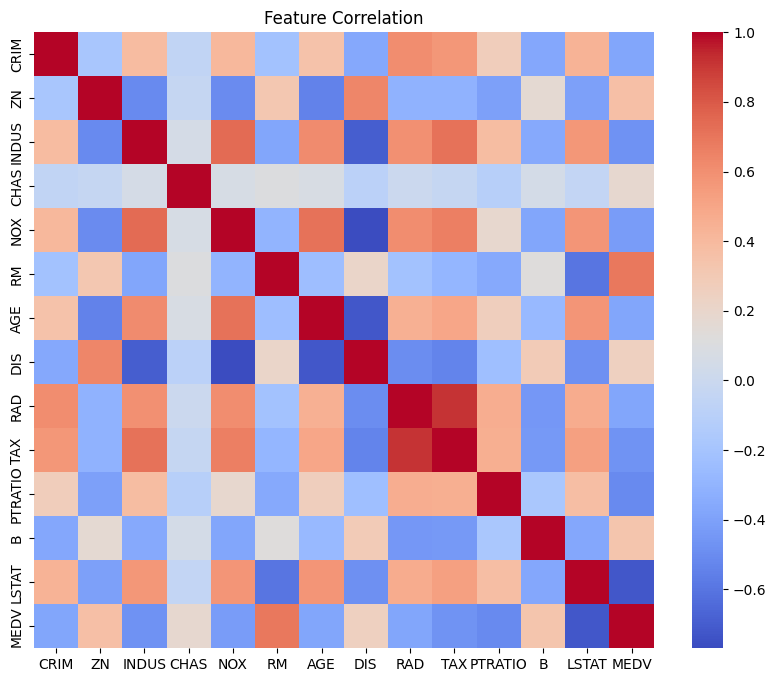

In [22]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

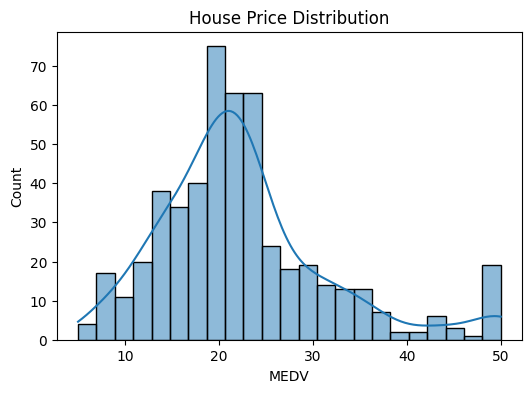

In [23]:
# Target distribution
plt.figure(figsize=(6,4))
sns.histplot(df['MEDV'], kde=True)
plt.title("House Price Distribution")
plt.show()

### 5. Split Features & Target

In [25]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

### 6. Normalize Data

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 7. Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

### 8. Build DNN Model

In [28]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # Output layer (regression)
])


D:\ANACONDA\envs\lpdeeplearn\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Train Model

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=16,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 605.9804 - mae: 22.6356 - val_loss: 490.4771 - val_mae: 20.4663
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 526.8661 - mae: 20.8609 - val_loss: 398.9398 - val_mae: 18.1923
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 399.7979 - mae: 17.8114 - val_loss: 271.1561 - val_mae: 14.6520
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 265.5898 - mae: 13.8864 - val_loss: 132.7393 - val_mae: 9.7606
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 132.8256 - mae: 9.1577 - val_loss: 55.0700 - val_mae: 5.5656
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 54.7154 - mae: 5.8542 - val_loss: 36.0784 - val_mae: 4.3198
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 45.9053 - mae: 5.1451 - val_loss: 29.0833 - val_mae: 3.7931
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 32.7137 - mae: 4.2443 - val_loss: 26.9000 - val_mae: 3.7055
Epoch 9/100
21/21 ━━━━━━

### 10. Evaluate Model

In [32]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [33]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [34]:
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 13.452088320470224
R2 Score: 0.8165635571935359


### 11. Visualization (Evaluation)

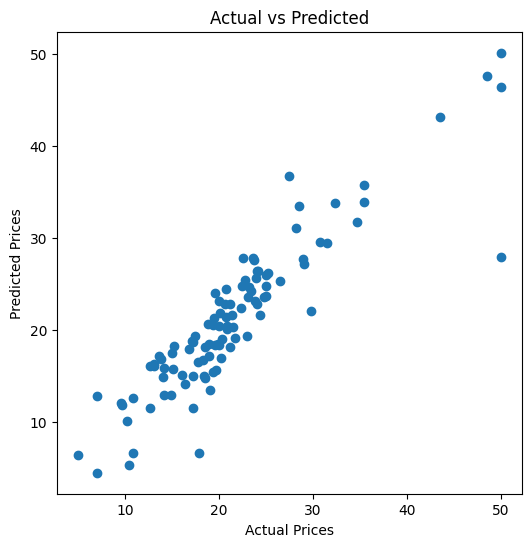

In [35]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

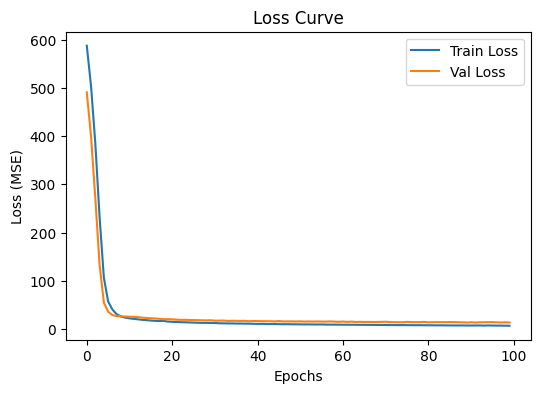

In [37]:
# Loss graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.xlabel("Epochs")        # X-axis
plt.ylabel("Loss (MSE)")    # Y-axis

plt.legend()
plt.title("Loss Curve")
plt.show()